Enter Excel/CSV file path: C:\Users\cugli\Desktop\冀东数据处理后结果\Processed_data.xlsx
✅ File loaded successfully! 12596 rows, 9 columns
📋 Columns: ['Sample ID', 'Reference No.', 'Sample No.', 'Rock name', 'Rock Type', 'Test object', 'Test instrument', 'Test institution', 'Test item']

Enter column names to plot (separate with commas): Test item

=== Processing column: Test item ===


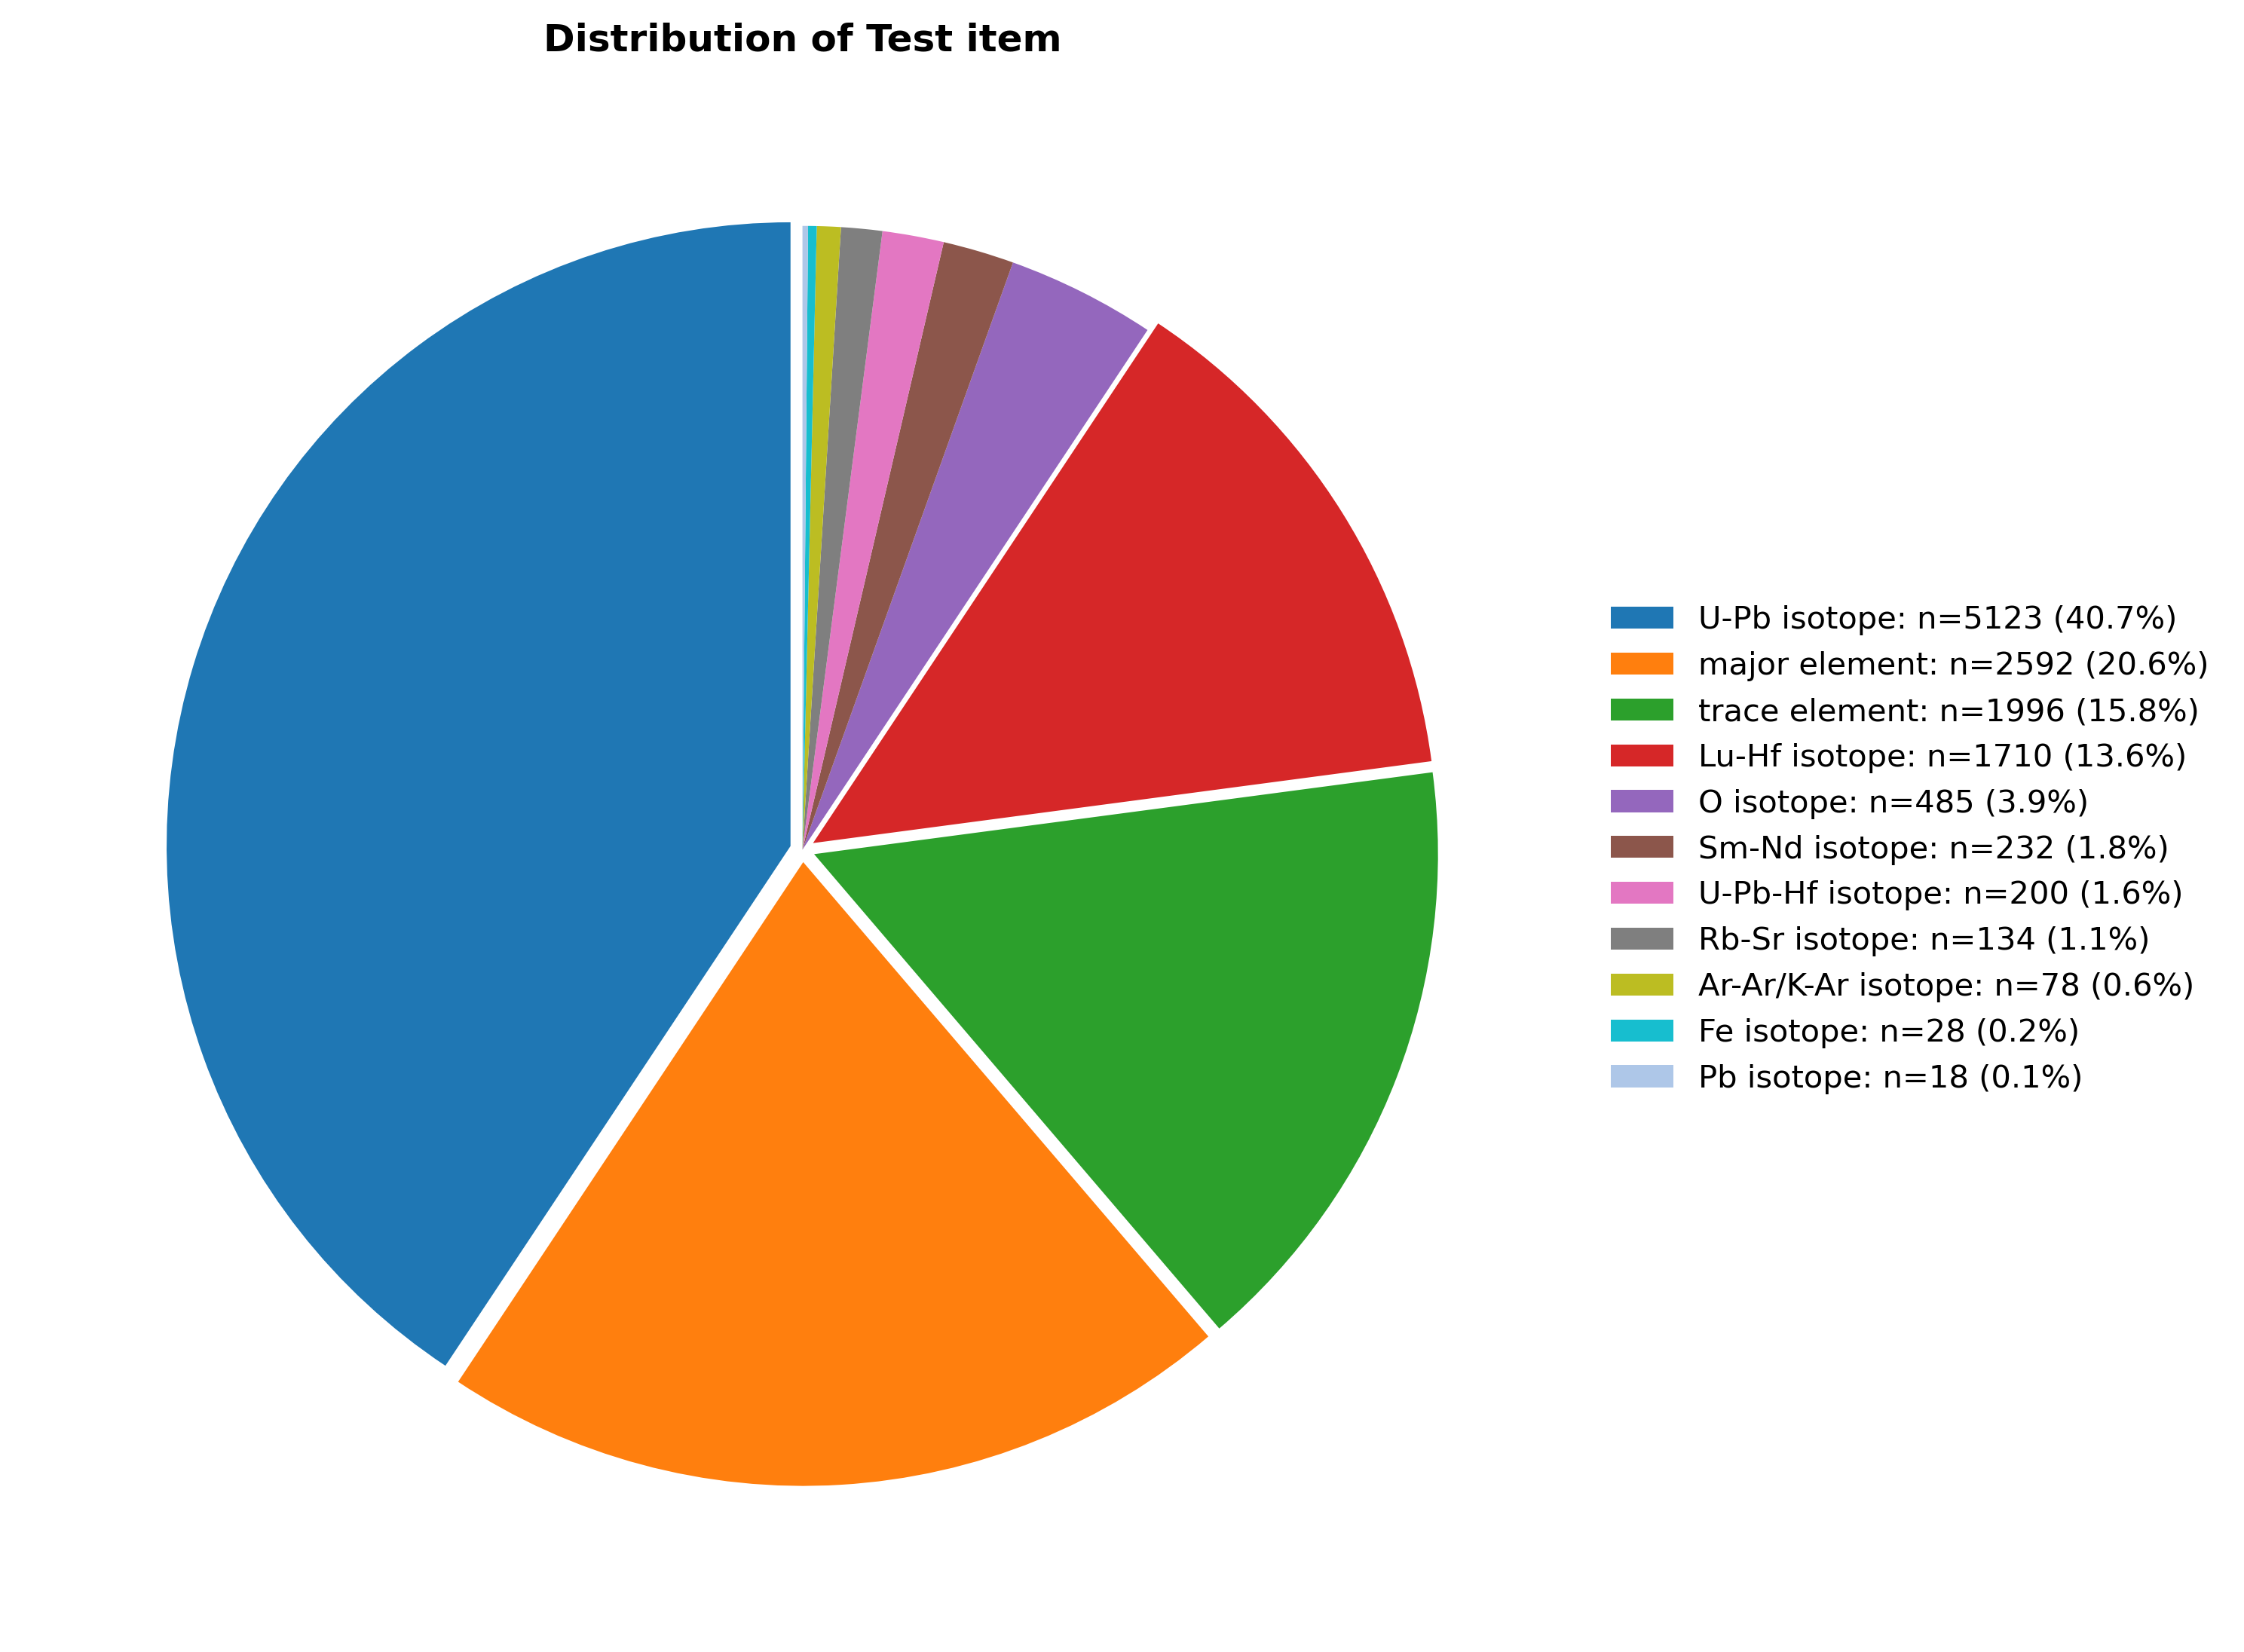

✅ Pie chart saved: Test item_PieChart.svg


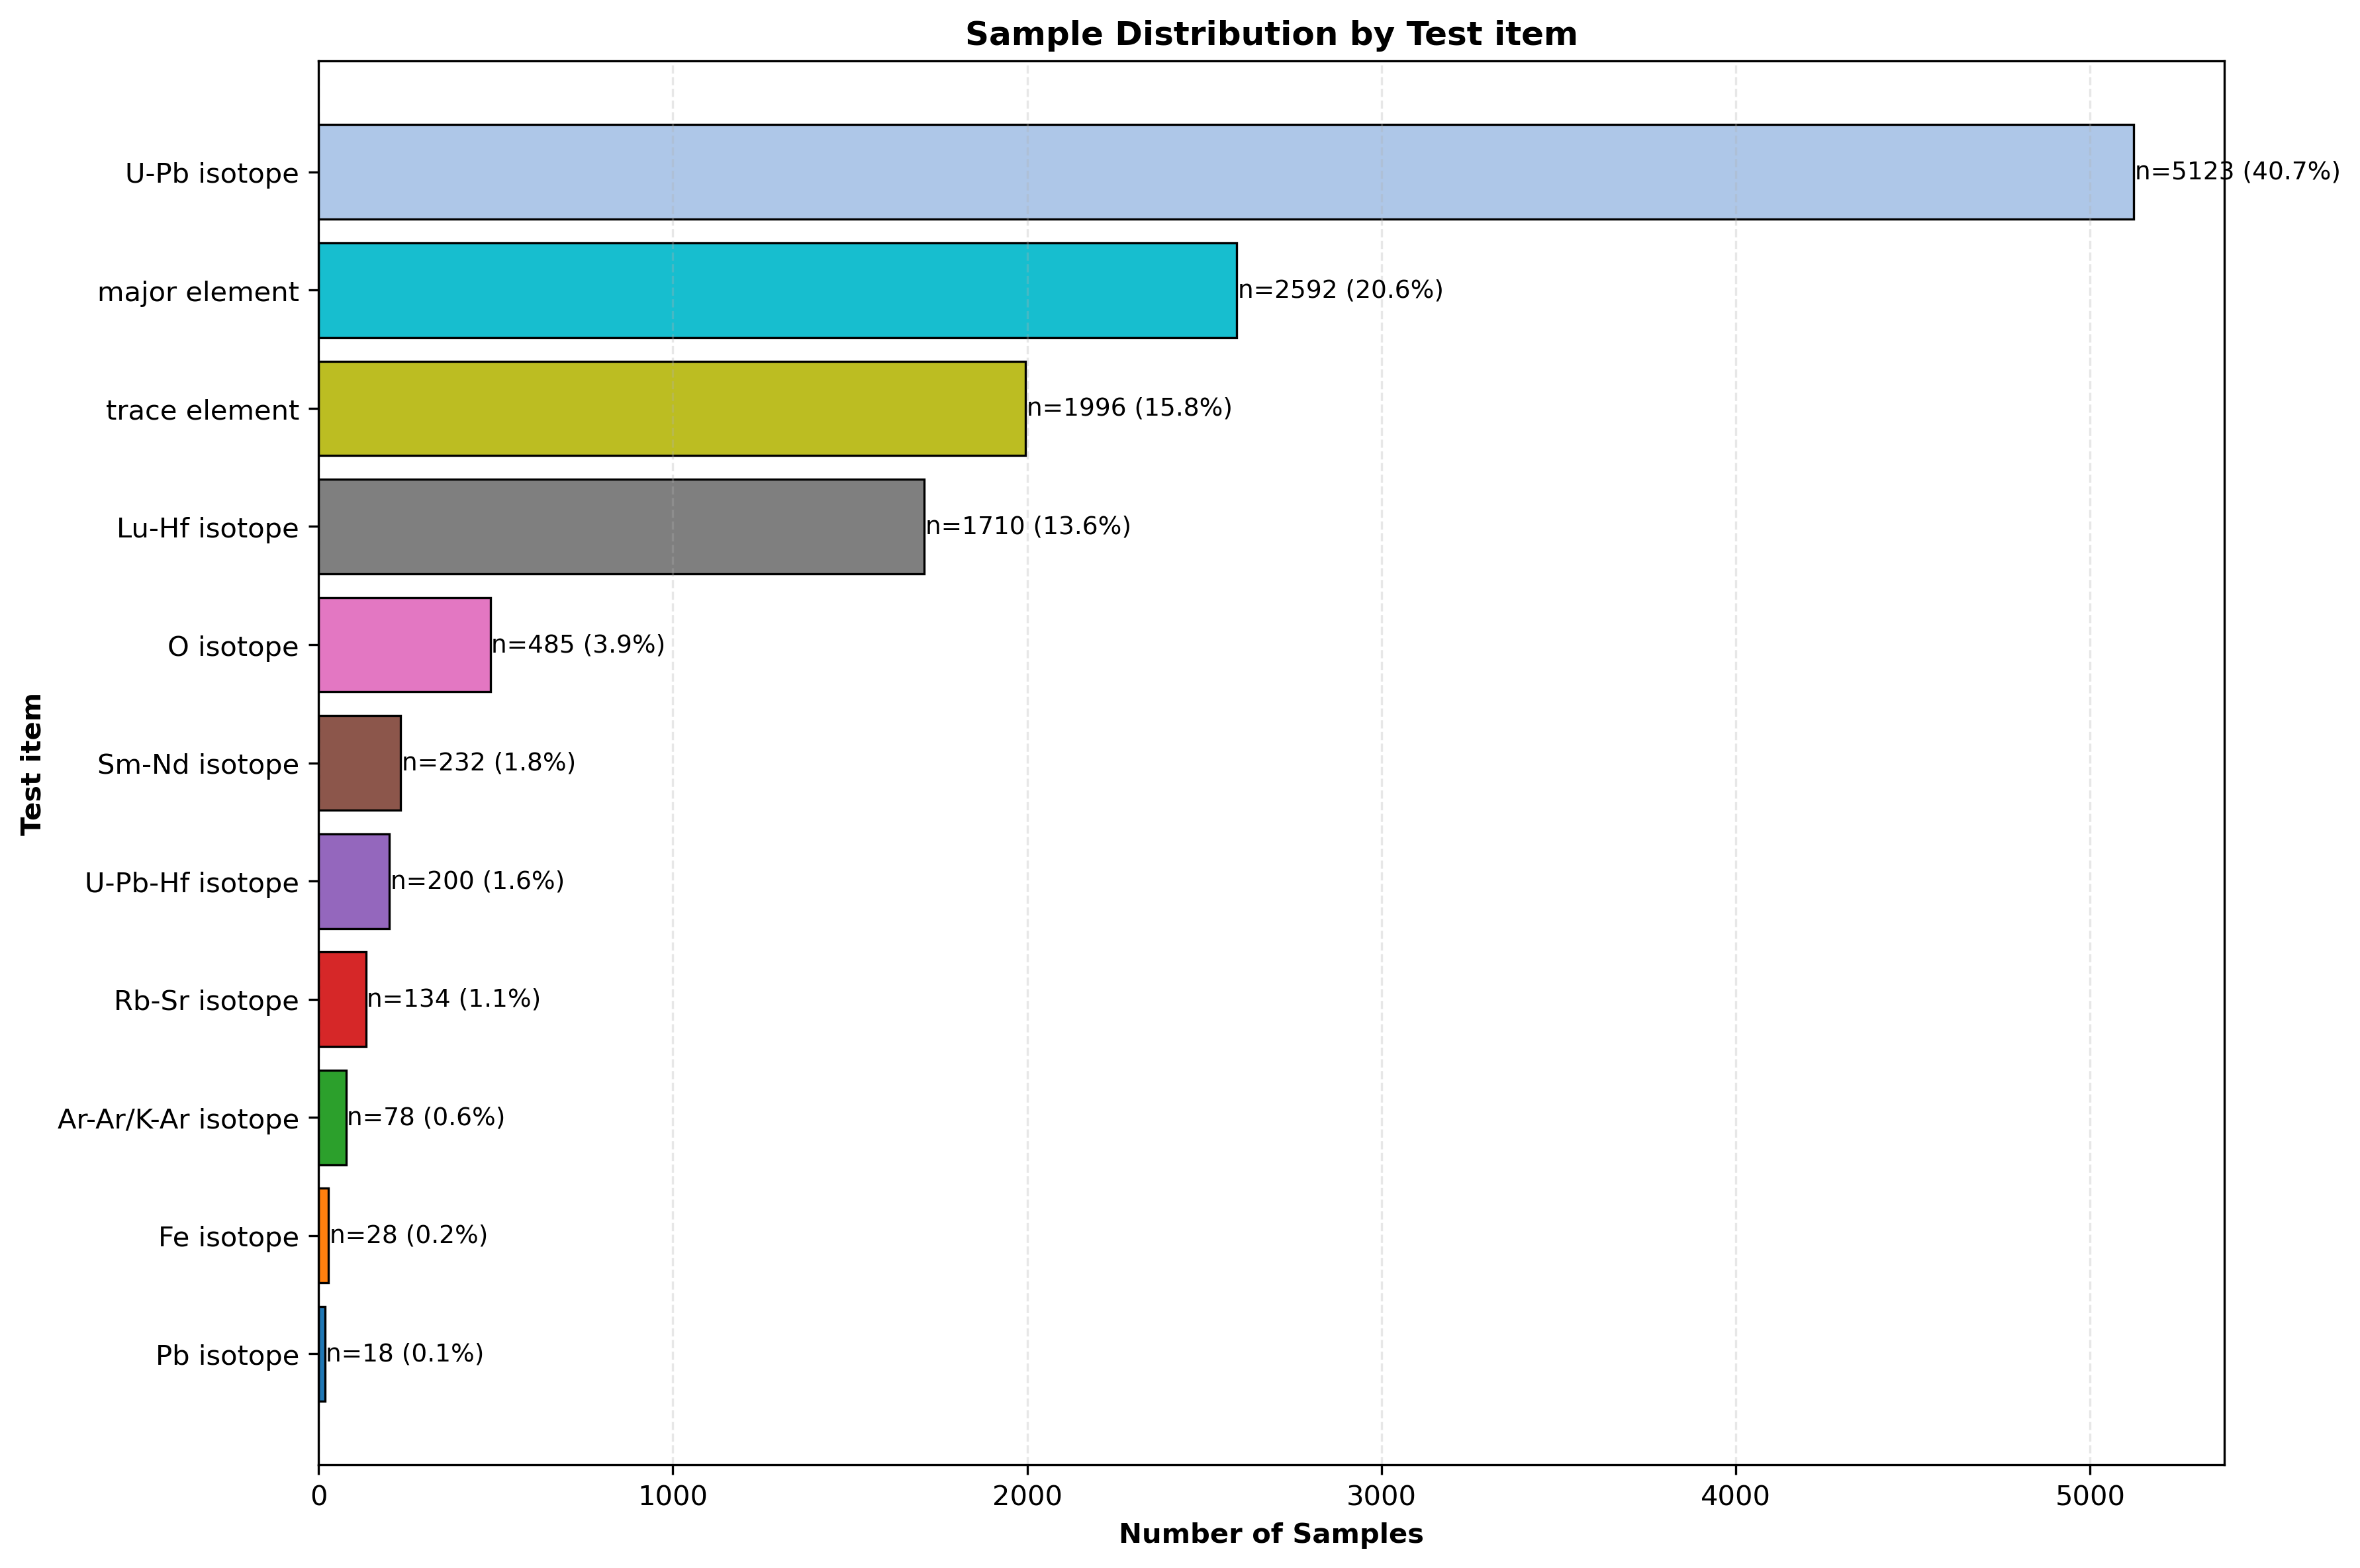

✅ Bar chart saved: Test item_HorizontalBar.svg

🎉 All tasks completed!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings

# ========== Suppress all warnings ==========
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore")

# ========== Jupyter Notebook plotting settings ==========
%matplotlib inline
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['savefig.bbox'] = 'tight'

# Top journal color palette
COLORS = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5'
]

# ========== Main function ==========
def main():
    file_path = input("Enter Excel/CSV file path: ").strip()
    
    try:
        if file_path.endswith('.csv'):
            df = pd.read_csv(file_path)
        else:
            df = pd.read_excel(file_path)

        print(f"✅ File loaded successfully! {df.shape[0]} rows, {df.shape[1]} columns")
        print(f"📋 Columns: {list(df.columns)}\n")
    except Exception as e:
        print(f"❌ Failed to load file: {e}")
        return

    target_cols = [c.strip() for c in input("Enter column names to plot (separate with commas): ").split(',')]

    for col in target_cols:
        if col not in df.columns:
            print(f"❌ Column not found: {col}")
            return

    for col_name in target_cols:
        print(f"\n=== Processing column: {col_name} ===")
        value_counts = df[col_name].value_counts(dropna=True)
        total = value_counts.sum()

        main_data = value_counts[value_counts >= 10]
        other_data = value_counts[value_counts < 10]
        other_sum = other_data.values.sum()

        if not other_data.empty:
            other_df = pd.DataFrame({
                'Name (Grouped as Others)': other_data.index,
                'Count': other_data.values
            })
            other_df.to_excel(f'{col_name}_Grouped_as_Others.xlsx', index=False)
            print(f"✅ Grouped table saved: {col_name}_Grouped_as_Others.xlsx")

        if other_sum > 0:
            main_data['Others'] = other_sum

        plot_data = main_data.sort_values(ascending=False)
        plot_total = plot_data.sum()

        # ========== Pie Chart ==========
        fig, ax = plt.subplots(figsize=(10, 10), dpi=300)
        explode = [0.02 if (cnt / plot_total * 100) > 5 else 0 for cnt in plot_data.values]

        wedges, texts = ax.pie(
            plot_data.values,
            explode=explode,
            colors=COLORS[:len(plot_data)],
            startangle=90,
            wedgeprops=dict(linewidth=0, edgecolor='none')
        )

        labels = [f"{name}: n={cnt} ({cnt/plot_total*100:.1f}%)" for name, cnt in plot_data.items()]
        
        ax.legend(wedges, labels, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=10, frameon=False)
        ax.set_title(f'Distribution of {col_name}', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        pie_name = f"{col_name}_PieChart.svg"
        plt.savefig(pie_name, bbox_inches='tight', format='svg')
        plt.close()
        print(f"✅ Pie chart saved: {pie_name}")

        # ========== Horizontal Bar Chart ==========
        bar_data = plot_data.sort_values(ascending=True)
        fig, ax = plt.subplots(figsize=(12, 8), dpi=300)
        
        bars = ax.barh(bar_data.index, bar_data.values,
                       color=COLORS[:len(bar_data)],
                       edgecolor='black', linewidth=0.8)

        for bar, cnt in zip(bars, bar_data.values):
            pct = cnt / plot_total * 100
            ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
                    f'n={cnt} ({pct:.1f}%)', fontsize=9, va='center')

        ax.set_xlabel('Number of Samples', fontsize=10, fontweight='bold')
        ax.set_ylabel(col_name, fontsize=10, fontweight='bold')
        ax.set_title(f'Sample Distribution by {col_name}', fontsize=12, fontweight='bold')
        ax.grid(axis='x', alpha=0.3, linestyle='--')
        
        plt.tight_layout()
        plt.show()
        
        bar_name = f"{col_name}_HorizontalBar.svg"
        plt.savefig(bar_name, bbox_inches='tight', format='svg')
        plt.close()
        print(f"✅ Bar chart saved: {bar_name}")

    print("\n🎉 All tasks completed!")

# ========== Run ==========
if __name__ == "__main__":
    main()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings

# ========== 强化警告屏蔽（包含user warning） ==========
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore")  # 兜底屏蔽所有警告

# ========== Jupyter Notebook 图片显示设置 ==========
%matplotlib inline
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['figure.figsize'] = (10, 8)  # 默认图大小
plt.rcParams['savefig.bbox'] = 'tight'    # 保存时自动裁剪空白

# 顶刊配色
COLORS = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5'
]

# ========== 主函数（适配Notebook交互） ==========
def main():
    # 建议直接在Notebook中修改文件路径，避免重复输入
    file_path = input("请输入 Excel/CSV 文件路径：").strip()
    
    try:
        if file_path.endswith('.csv'):
            df = pd.read_csv(file_path)
        else:
            df = pd.read_excel(file_path)

        print(f"✅ 文件读取成功！{df.shape[0]} 行 {df.shape[1]} 列")
        print(f"📋 列名：{list(df.columns)}\n")
    except Exception as e:
        print(f"❌ 读取失败：{e}")
        return

    # 输入要绘图的列
    target_cols = [c.strip() for c in input("请输入要绘图的列名（多列用英文逗号分隔）：").split(',')]

    # 校验列是否存在
    for col in target_cols:
        if col not in df.columns:
            print(f"❌ 列不存在：{col}")
            return

    # 逐列绘图
    for col_name in target_cols:
        print(f"\n=== 处理列：{col_name} ===")
        value_counts = df[col_name].value_counts(dropna=True)
        total = value_counts.sum()

        # 分组：数量≥10的保留，<10的归为Others
        main_data = value_counts[value_counts >= 10]
        other_data = value_counts[value_counts < 10]
        other_sum = other_data.values.sum()

        # 保存归类表
        if not other_data.empty:
            other_df = pd.DataFrame({
                'Name (Grouped as Others)': other_data.index,
                'Count': other_data.values
            })
            other_df.to_excel(f'{col_name}_Grouped_as_Others.xlsx', index=False)
            print(f"✅ 已生成归类表：{col_name}_Grouped_as_Others.xlsx")

        # 合并Others
        if other_sum > 0:
            main_data['Others'] = other_sum

        plot_data = main_data.sort_values(ascending=False)
        plot_total = plot_data.sum()

        # ========== 饼图（Notebook内嵌显示） ==========
        fig, ax = plt.subplots(figsize=(10, 10), dpi=300)

        # 突出显示占比>5%的部分
        explode = [0.02 if (cnt / plot_total * 100) > 5 else 0 for cnt in plot_data.values]

        wedges, texts = ax.pie(
            plot_data.values,
            explode=explode,
            colors=COLORS[:len(plot_data)],
            startangle=90,
            wedgeprops=dict(linewidth=0, edgecolor='none')
        )

        # 生成标签（名称+数量+百分比）
        labels = [f"{name}: n={cnt} ({cnt/plot_total*100:.1f}%)" for name, cnt in plot_data.items()]
        
        # 添加图例
        ax.legend(wedges, labels, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=10, frameon=False)
        ax.set_title(f'Distribution of {col_name}', fontsize=12, fontweight='bold')
        
        # Notebook中显示图片
        plt.tight_layout()
        plt.show()
        
        # 保存矢量图
        pie_name = f"{col_name}_PieChart.svg"
        plt.savefig(pie_name, bbox_inches='tight', format='svg')
        plt.close()
        print(f"✅ 饼图已保存：{pie_name}")

        # ========== 水平条形图（Notebook内嵌显示） ==========
        bar_data = plot_data.sort_values(ascending=True)
        fig, ax = plt.subplots(figsize=(12, 8), dpi=300)
        
        # 绘制条形图
        bars = ax.barh(bar_data.index, bar_data.values, 
                       color=COLORS[:len(bar_data)], 
                       edgecolor='black', linewidth=0.8)

        # 添加数值标签
        for bar, cnt in zip(bars, bar_data.values):
            pct = cnt / plot_total * 100
            ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
                    f'n={cnt} ({pct:.1f}%)', fontsize=9, va='center')

        # 设置标签和标题
        ax.set_xlabel('Number of Samples', fontsize=10, fontweight='bold')
        ax.set_ylabel(col_name, fontsize=10, fontweight='bold')
        ax.set_title(f'Sample Distribution by {col_name}', fontsize=12, fontweight='bold')
        ax.grid(axis='x', alpha=0.3, linestyle='--')
        
        # Notebook中显示图片
        plt.tight_layout()
        plt.show()
        
        # 保存矢量图
        bar_name = f"{col_name}_HorizontalBar.svg"
        plt.savefig(bar_name, bbox_inches='tight', format='svg')
        plt.close()
        print(f"✅ 条形图已保存：{bar_name}")

    print("\n🎉 全部完成！")

# ========== 执行主函数 ==========
if __name__ == "__main__":
    main()

请输入 Excel/CSV 文件路径：1
❌ 读取失败：[Errno 2] No such file or directory: '1'


Enter Excel/CSV file path: C:\Users\cugli\Desktop\冀东数据处理后结果\JD_DATA_ID.xlsx
✅ File loaded successfully! 1732 rows, 10 columns
📋 Columns: ['Sampel ID', 'Reference No.', 'Sample No.', 'Rock name', 'Rock Type', 'Geological unit', 'Geographic location', 'latitude', 'longitude', 'Drilling depth']

Enter column names to plot (separate with commas): Rock Type

=== Processing column: Rock Type ===
✅ Grouped table saved: Rock Type_Grouped_as_Others.xlsx


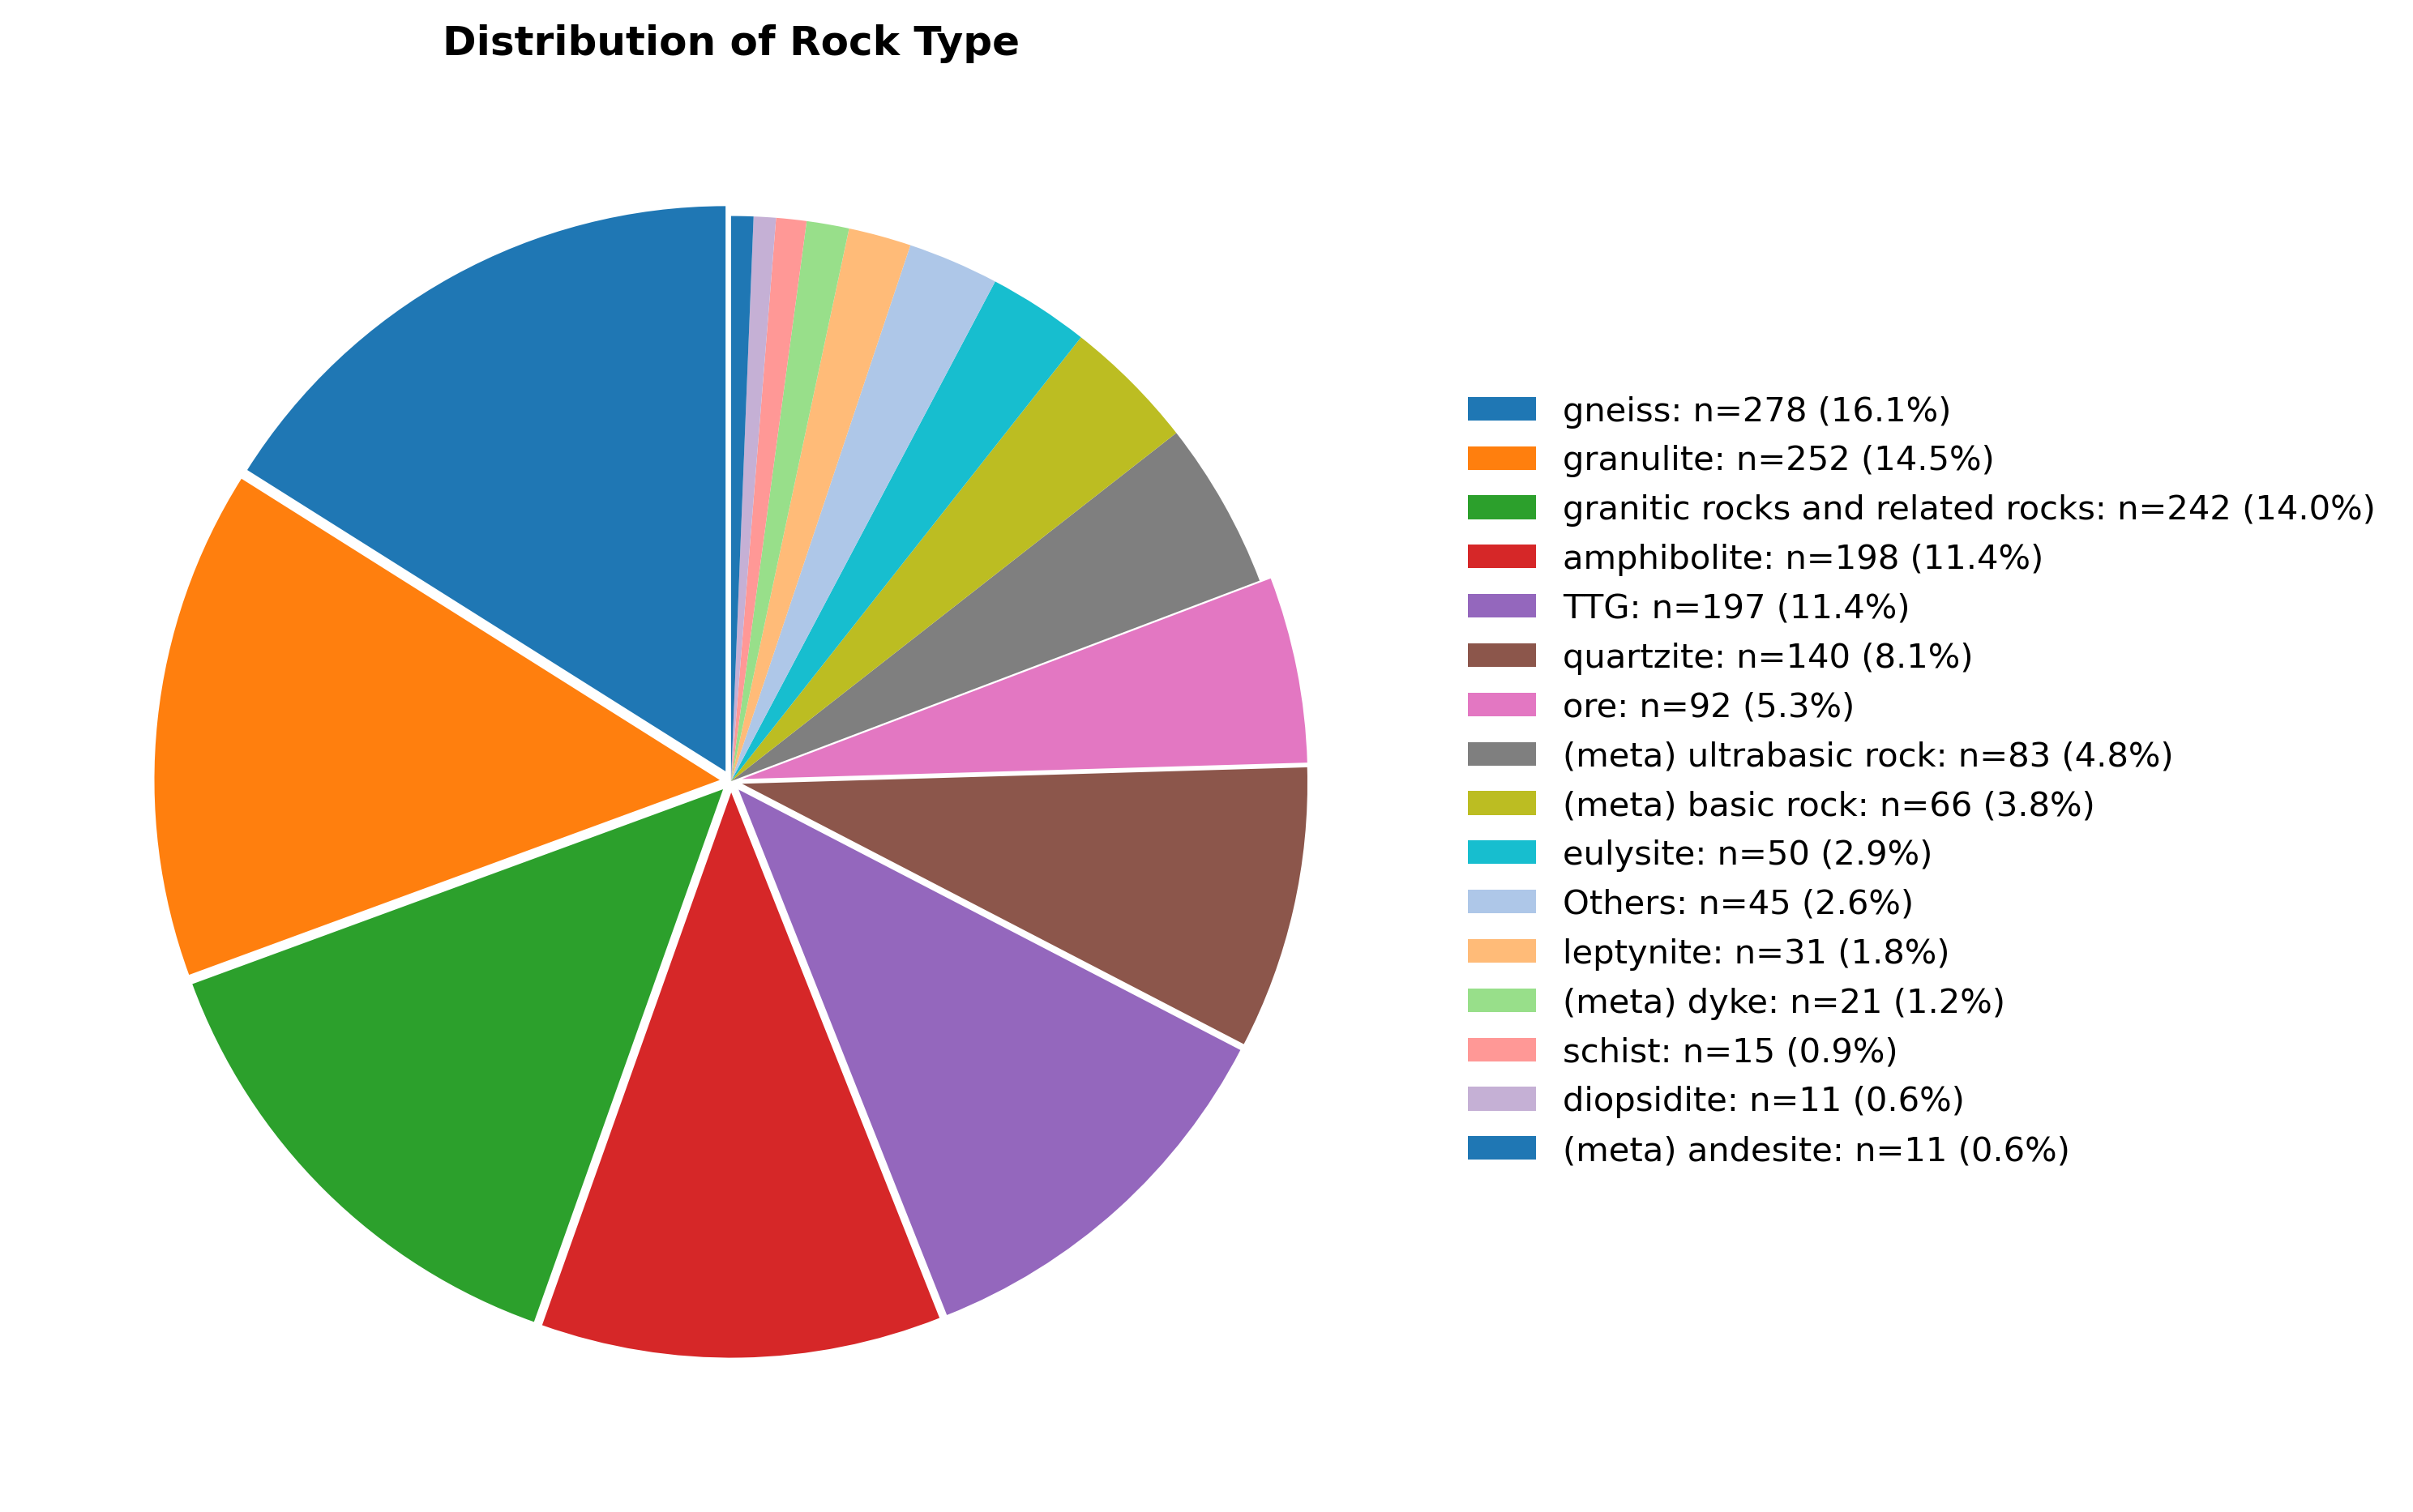

✅ Pie chart saved: Rock Type_PieChart.svg


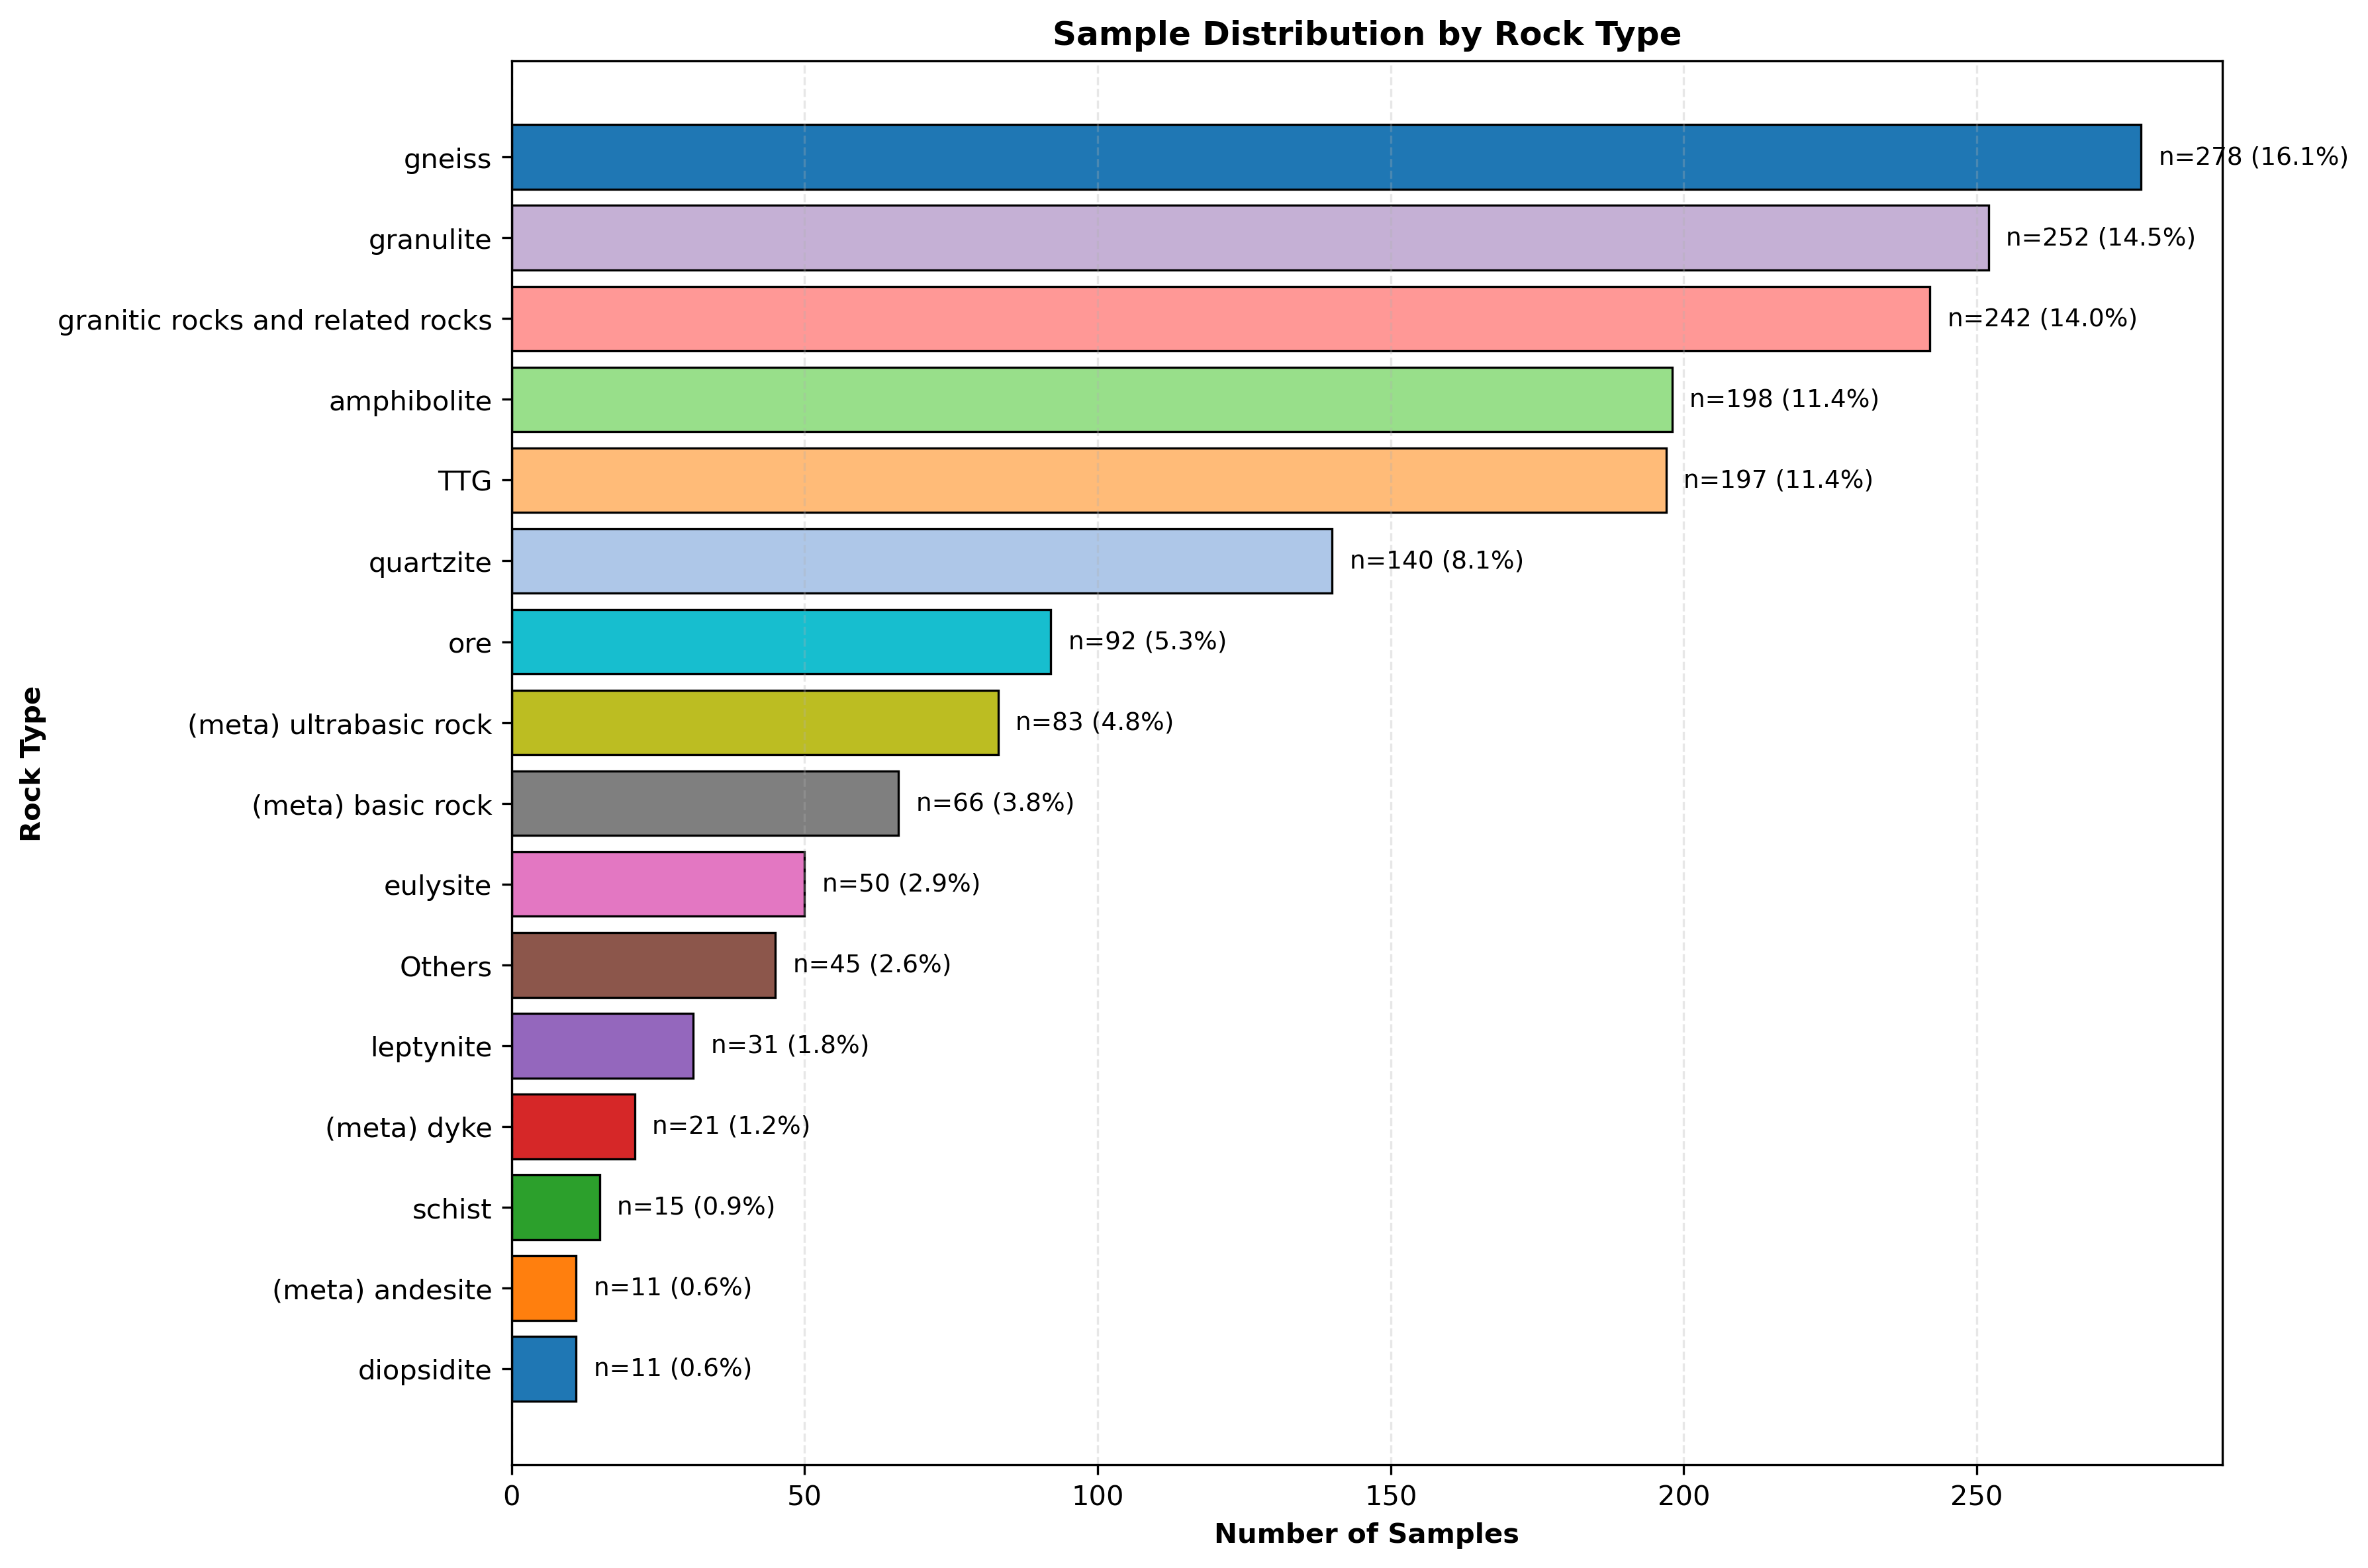

✅ Bar chart saved: Rock Type_HorizontalBar.svg

🎉 All tasks completed!


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings

# ========== Suppress all warnings ==========
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore")

# ========== Jupyter Notebook plotting settings ==========
%matplotlib inline
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['savefig.bbox'] = 'tight'

# Top journal color palette
COLORS = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5'
]

# ========== Main function ==========
def main():
    file_path = input("Enter Excel/CSV file path: ").strip()
    
    try:
        if file_path.endswith('.csv'):
            df = pd.read_csv(file_path)
        else:
            df = pd.read_excel(file_path)

        print(f"✅ File loaded successfully! {df.shape[0]} rows, {df.shape[1]} columns")
        print(f"📋 Columns: {list(df.columns)}\n")
    except Exception as e:
        print(f"❌ Failed to load file: {e}")
        return

    target_cols = [c.strip() for c in input("Enter column names to plot (separate with commas): ").split(',')]

    for col in target_cols:
        if col not in df.columns:
            print(f"❌ Column not found: {col}")
            return

    for col_name in target_cols:
        print(f"\n=== Processing column: {col_name} ===")
        value_counts = df[col_name].value_counts(dropna=True)
        total = value_counts.sum()

        main_data = value_counts[value_counts >= 10]
        other_data = value_counts[value_counts < 10]
        other_sum = other_data.values.sum()

        if not other_data.empty:
            other_df = pd.DataFrame({
                'Name (Grouped as Others)': other_data.index,
                'Count': other_data.values
            })
            other_df.to_excel(f'{col_name}_Grouped_as_Others.xlsx', index=False)
            print(f"✅ Grouped table saved: {col_name}_Grouped_as_Others.xlsx")

        if other_sum > 0:
            main_data['Others'] = other_sum

        plot_data = main_data.sort_values(ascending=False)
        plot_total = plot_data.sum()

        # ========== Pie Chart ==========
        fig, ax = plt.subplots(figsize=(10, 10), dpi=300)

        explode = [0.02 if (cnt / plot_total * 100) > 5 else 0 for cnt in plot_data.values]

        wedges, texts = ax.pie(
            plot_data.values,
            explode=explode,
            colors=COLORS[:len(plot_data)],
            startangle=90,
            wedgeprops=dict(linewidth=0, edgecolor='none')
        )

        labels = [f"{name}: n={cnt} ({cnt/plot_total*100:.1f}%)" for name, cnt in plot_data.items()]
        
        ax.legend(wedges, labels, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=10, frameon=False)
        ax.set_title(f'Distribution of {col_name}', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        pie_name = f"{col_name}_PieChart.svg"
        plt.savefig(pie_name, bbox_inches='tight', format='svg')
        plt.close()
        print(f"✅ Pie chart saved: {pie_name}")

        # ========== Horizontal Bar Chart ==========
        bar_data = plot_data.sort_values(ascending=True)
        fig, ax = plt.subplots(figsize=(12, 8), dpi=300)
        
        bars = ax.barh(bar_data.index, bar_data.values, 
                       color=COLORS[:len(bar_data)], 
                       edgecolor='black', linewidth=0.8)

        for bar, cnt in zip(bars, bar_data.values):
            pct = cnt / plot_total * 100
            ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
                    f'n={cnt} ({pct:.1f}%)', fontsize=9, va='center')

        ax.set_xlabel('Number of Samples', fontsize=10, fontweight='bold')
        ax.set_ylabel(col_name, fontsize=10, fontweight='bold')
        ax.set_title(f'Sample Distribution by {col_name}', fontsize=12, fontweight='bold')
        ax.grid(axis='x', alpha=0.3, linestyle='--')
        
        plt.tight_layout()
        plt.show()
        
        bar_name = f"{col_name}_HorizontalBar.svg"
        plt.savefig(bar_name, bbox_inches='tight', format='svg')
        plt.close()
        print(f"✅ Bar chart saved: {bar_name}")

    print("\n🎉 All tasks completed!")

# ========== Run ==========
if __name__ == "__main__":
    main()